# Project 1
### Kwatcho Mahinanda


## Project Goal 
The goal of this project is to demonstrate web scraping techniques by automating a product search on Nike.com, extracting specific details about the search results, and performing basic data analysis.

## Overview 
This analysis uses data scraped from the Nike official website ([https://www.nike.com/](https://www.nike.com/)) using Selenium browser automation. Data was collected on October 21, 2025.

### Data Collected (Search: "air max 90")
The dataset includes the following details for shoes listed in the search results for "air max 90":
* Product Name (e.g., "Nike Air Max 90")
* Product Type/Subtitle (e.g., "Men's Shoes", "Big Kids' Shoe")
* Price ($)
* Number of Colorways Available

### Specific Search Criteria
Data collection focused on a single automated search query:
* **Website:** Nike.com
* **Search Term:** "air max 90"

# Methodology

This project involves scraping product data from Nike.com after an automated search, using `selenium` for browser automation and `pandas`, `matplotlib`, and `seaborn` for data structuring and analysis.

## 1. Setup and Website Interaction 
* **Import Packages:** Import necessary Python libraries (`selenium`, `webdriver_manager`, `pandas`, `re`, `time`, `traceback`, `matplotlib`, `seaborn`).
* **Initialize Driver:** Start a Selenium WebDriver instance (Chrome) using `webdriver_manager`.
* **Navigate:** Open the Nike.com homepage. 
* **Handle Consent (Attempted):** Include a brief wait and attempt to automatically click any potential cookie consent buttons (using generic locators).
* **Automate Search:**
    * Locate and click the **search icon button** (`id="nav-search-icon"`) to reveal the search input field.
    * Wait for the search input field (`id="gn-search-input"`) to become interactable.
    * Clear the input field.
    * Type the search term **"air max 90"** into the input field.
    * Simulate pressing the **Enter key** to submit the search.
* **Wait for Results:** Explicitly wait for the search results page to load by looking for a known element container that holds the product results (e.g., `div[class*='product-grid']`).

## 2. Data Scraping and Structuring 
* **Identify Elements:** On the search results page, identify the main container element for a single product card (e.g., `div[class*='product-card ']`). Within each container, locate the specific elements for:
    * Product Name (`div.product-card__title`)
    * Product Type/Subtitle (`div.product-card__subtitle`)
    * Price (`div[data-testid='product-price']`)
    * Colorway container (`div.product-card__colorways`) and individual colorway links (`a.colorway`) inside it.
* **Loop & Extract:**
    * Find all product card containers on the results page.
    * Loop through each container found.
    * Inside the loop, use `card.find_element()` to locate the name, type, and price elements *relative to the current card*.
    * Extract the text content for name and type.
    * Extract the price text, clean it, and store as a number.
    * Find all colorway link elements (`a.colorway`) within the card and count them using `len()` to get the number of colorways.
    * Store the extracted data (Name, Type, Price, Color Count) for each product in a list of dictionaries.
* **Create Dataset:** Convert the list of dictionaries into a pandas DataFrame (`df_results`).

## 3. Data Validation 
* **Verify Product Count:** Compare the number of search results reported by Nike on the webpage to the number of rows in the generated pandas DataFrame (`len(df_results)`).
* **Check for Completeness:** Use `df_results.isnull().sum()` to check for missing data points in the scraped columns.

## 4. Data Analysis 
* **Descriptive Statistics (Price):** Calculate and present summary statistics for the 'Price' column using `df_results['Price'].describe()` (includes mean, min, max) and calculate variance using `df_results['Price'].var()`.
* **Visualizations:**
    * Create a **bar chart** (`seaborn.countplot`) showing the count of products for each 'Type' category, ordered by frequency, with types on the y-axis.
    * Create a **box plot** (`seaborn.boxplot`) displaying the distribution of 'Price' on the x-axis for each 'Type' category on the y-axis, ordered by median price.
    * Create a **histogram** (`seaborn.histplot`) for the 'Price' column, including a Kernel Density Estimate (KDE) curve and using 10 bins, to visualize the overall price distribution.

In [11]:
#------------------- IMPORT PACKAGES FOR DATA PROCESSING ----------------------#

import os, re
import traceback
import matplotlib.pyplot as plt
import seaborn as sns 

# Manage datasets
import pandas as pd

# Work with time data
import time 

# Conduct HTTP requests
import requests

# Construct tree structure of HTML data
import html5lib

# Parse HTML data obtained from scraping
from bs4 import BeautifulSoup

# Import webdriver for chrome
from webdriver_manager.chrome import ChromeDriverManager


from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager


# Automate navigating within browser (SELENIUM)
#------ Key: Manage keys
#------ Select: Obtain features from website
#------ WebDriverWait: Add wait times implicitly
#------ By: Use common information locator strategies
#------ EC and Options: Browser configuration
#------ remote.command: Check whether browser is active

from selenium import webdriver #to automate the navigating within the browser
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.keys    import Keys
from selenium.webdriver.support.ui     import Select
from selenium.webdriver.support.ui     import WebDriverWait 
from selenium.webdriver.common.by      import By
from selenium.webdriver.support        import expected_conditions as EC
from selenium.webdriver.chrome.options import Options #to use properties of the chrome webbrowser
from selenium.webdriver.remote.command import Command # Use to check whether the web driver is active

In [12]:
# Initialize Driver and Starting URL

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service = Service(ChromeDriverManager().install()))
options = webdriver.ChromeOptions()
starting_url = 'https://www.nike.com/'
driver.get(starting_url)

In [13]:
# Search for "air max 90"
try:
    print("Performing Search for 'air max 90'")
    search_icon_button_id = "nav-search-icon"
    search_input_id = "gn-search-input"
    wait_long = WebDriverWait(driver, 15)

    # 1. Click the Search Icon Button
    print(f"Looking for search icon button with ID: '{search_icon_button_id}'")
    search_icon_button = wait_long.until(EC.element_to_be_clickable((By.ID, search_icon_button_id)))
    search_icon_button.click()
    print("Clicked the search icon button.")
    time.sleep(1) # Wait for input field to appear/become active

    # 2. Find, type into, and submit the search input field
    print(f"Looking for search input with ID: '{search_input_id}'")
    search_input = wait_long.until(EC.element_to_be_clickable((By.ID, search_input_id)))

    print("Clearing and typing search term...")
    search_input.clear()
    search_input.send_keys("air max 90")
    time.sleep(0.5)

    print("Pressing Enter...")
    search_input.send_keys(Keys.RETURN)
    print("Search submitted.")

    # Wait for Search Results Page
    print("\nWaiting for search results page to load...")
    # Using a more specific wait: wait for the container holding product cards
    # Inspect the results page to find a good container class, e.g., 'product-grid' or similar
    results_container_xpath = "//div[contains(@class, 'product-grid')]" # Example XPath, ADJUST THIS!
    print(f"Waiting for results container (XPath: {results_container_xpath})...")
    wait_long.until(EC.presence_of_element_located((By.XPATH, results_container_xpath)))
    print("Results page loaded (found results container).")
    time.sleep(3) # Give results time to render

except Exception as e:
    print(f"Error during search process: {e}")
    traceback.print_exc()



Performing Search for 'air max 90'
Looking for search icon button with ID: 'nav-search-icon'
Clicked the search icon button.
Looking for search input with ID: 'gn-search-input'
Clearing and typing search term...
Pressing Enter...
Search submitted.

Waiting for search results page to load...
Waiting for results container (XPath: //div[contains(@class, 'product-grid')])...
Results page loaded (found results container).


In [14]:
# Scrape Search Results
scraped_data = []
wait = WebDriverWait(driver, 10)

try:
    print("Scraping Search Results")
    # Find all product card containers
    # Using CSS Selector: Find divs whose class attribute contains 'product-card '
    # This is a bit flexible if the full class name varies slightly
    product_container_selector = "div[class*='product-card ']"
    print(f"Looking for product containers using selector: '{product_container_selector}'")
    product_cards = wait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, product_container_selector)))
    print(f"Found {len(product_cards)} potential product cards.")

    if not product_cards:
        print("No product cards found with that selector. Check the selector.")
    else:
        # Loop through each product card found
        for card in product_cards:
            try:
                # Extract Data (use .find_element relative to the card)

                # Name
                name_element = card.find_element(By.CSS_SELECTOR, "div.product-card__title")
                name = name_element.text

                # Type/Subtitle
                subtitle_element = card.find_element(By.CSS_SELECTOR, "div.product-card__subtitle")
                shoe_type = subtitle_element.text

                # Price
                price_element = card.find_element(By.CSS_SELECTOR, "div[data-testid='product-price']")
                price_text = price_element.text
                # Clean price: remove '$', ',', convert to float
                price = float(re.sub(r'[^\d.]', '', price_text))

                # Color Count
                color_elements = card.find_elements(By.CSS_SELECTOR, "div.product-card__colorways a.colorway")
                color_count = len(color_elements)

                # Append data to list
                scraped_data.append({
                    "Name": name,
                    "Type": shoe_type,
                    "Price": price,
                    "Color Count": color_count
                })
                print(f"  Scraped: {name} | Type: {shoe_type} | Price: {price} | Colors: {color_count}")

            except Exception as item_e:
                # If one card fails, print error and continue with the next
                print(f"Error scraping details from one card: {item_e}")
                # Optional: try scraping just the name if other parts fail
                try:
                     name = card.find_element(By.CSS_SELECTOR, "div.product-card__title").text
                     print(f"-> Failed card partial name: {name}")
                except:
                     print("-> Failed card, couldn't even get name.")


except Exception as e:
    print(f"Major error finding or looping through product cards: {e}")
    traceback.print_exc()


Scraping Search Results
Looking for product containers using selector: 'div[class*='product-card ']'
Found 24 potential product cards.
  Scraped: Nike Air Max 90 Premium | Type: Men's Shoes with Reflective Accents | Price: 145.0 | Colors: 5
  Scraped: Nike Air Max 90 | Type: Women's Shoes | Price: 135.0 | Colors: 5
  Scraped: Nike Air Max 90 | Type: Men's Shoes | Price: 135.0 | Colors: 5
  Scraped: Nike Air Max 90 EasyOn | Type: Little Kids' Shoes | Price: 82.0 | Colors: 5
  Scraped: Nike Air Max 90 LTR | Type: Big Kids’ Shoes | Price: 102.0 | Colors: 5
  Scraped: Nike Air Max 90 | Type: Men's Shoes | Price: 135.0 | Colors: 0
  Scraped: Nike Air Max 90 G | Type: Golf Shoes | Price: 145.0 | Colors: 5
  Scraped: Nike Air Max 90 By You | Type: Custom Men's Shoes | Price: 165.0 | Colors: 5
  Scraped: Air Max 90 LTR | Type: Men's Shoes | Price: 145.0 | Colors: 0
  Scraped: Nike Air Max 90 | Type: Big Kids' Shoes with Reflective Accents | Price: 112.0 | Colors: 0
  Scraped: Nike Air Max 90 B

In [15]:
# Create DataFrame
df_results = pd.DataFrame(scraped_data)
df_results.head()
# Export DataFrame to CSV
csv_filename = 'nike_air_max_90_results.csv'
df_results.to_csv(csv_filename, index=False) 
print(f"Data exported successfully to {csv_filename}")


Data exported successfully to nike_air_max_90_results.csv


In [16]:
# Validation and Analysis
print(f"Total items viewed from webpage: 34")
print(f"Total items scraped into DataFrame: {len(df_results)}")
print("\nMissing values check:")
print(df_results.isnull().sum()) # Should ideally be all zeros




Total items viewed from webpage: 34
Total items scraped into DataFrame: 24

Missing values check:
Name           0
Type           0
Price          0
Color Count    0
dtype: int64


In [17]:
print("Price Analysis")
if not df_results.empty and 'Price' in df_results.columns:
    print(df_results['Price'].describe()) # Shows count, mean, std, min, 25%, 50%, 75%, max

    # You can also print them individually for clarity:
    print(f"\nMean Price: ${df_results['Price'].mean():.2f}")
    print(f"Price Variance: {df_results['Price'].var():.2f}")
    print(f"Min Price: ${df_results['Price'].min():.2f}")
    print(f"Max Price: ${df_results['Price'].max():.2f}")
else:
    print("Cannot perform price analysis. DataFrame might be empty or missing 'Price' column.")

Price Analysis
count     24.000000
mean     113.791667
std       41.953369
min       30.000000
25%       93.750000
50%      127.500000
75%      145.000000
max      165.000000
Name: Price, dtype: float64

Mean Price: $113.79
Price Variance: 1760.09
Min Price: $30.00
Max Price: $165.00


Plotting Histogram for Price


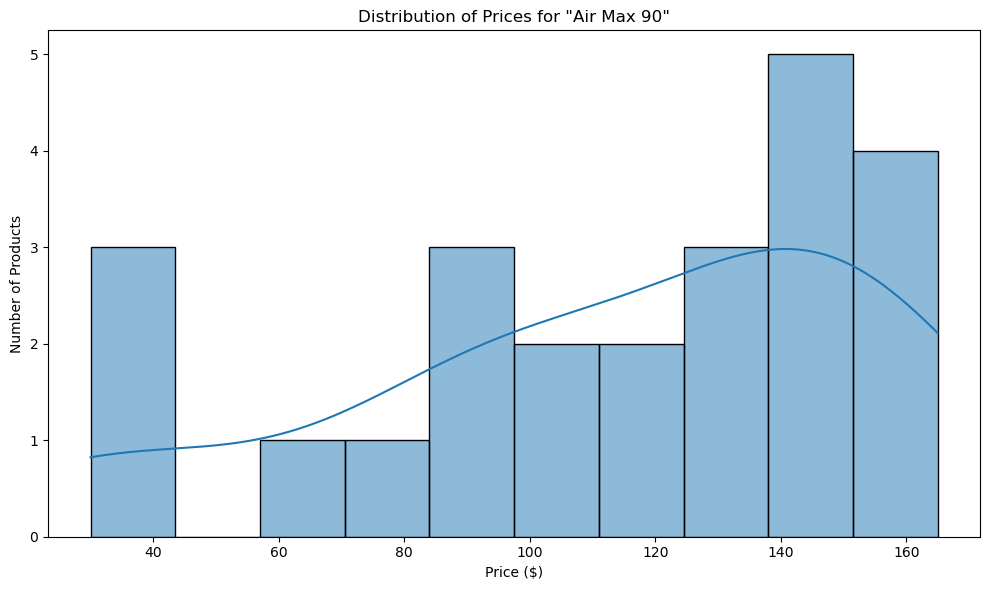

In [18]:
print("Plotting Histogram for Price")

if not df_results.empty and 'Price' in df_results.columns:
        # Create the plot
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_results, x='Price', kde=True, bins=10) # kde adds a smooth density curve, bins controls number of bars

    # Add labels and title
    plt.title('Distribution of Prices for "Air Max 90"')
    plt.xlabel('Price ($)')
    plt.ylabel('Number of Products')

    # Improve layout and display the plot
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot price histogram. DataFrame might be empty or missing 'Price' column.")

Plotting Box Plot for Price by Product Type


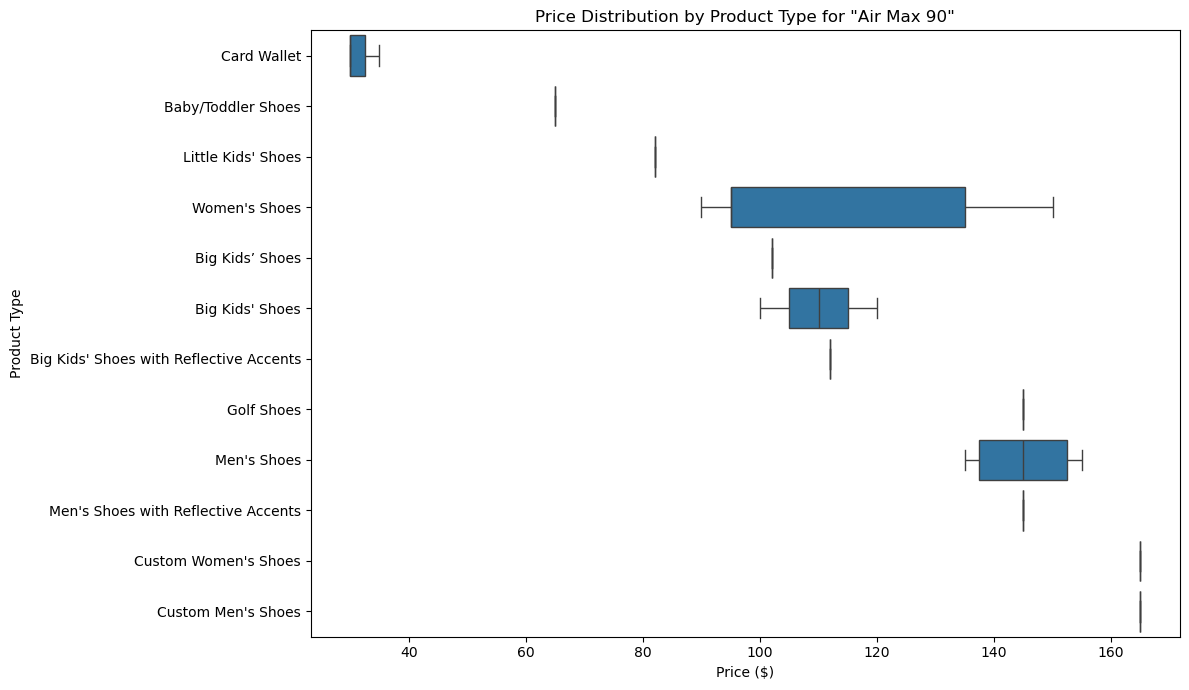

In [19]:
print("Plotting Box Plot for Price by Product Type")

if not df_results.empty and 'Price' in df_results.columns and 'Type' in df_results.columns:

    # Create the plot
    plt.figure(figsize=(12, 7)) # Adjust figure size

    # Create the boxplot, ordering categories by median price 
    median_order = df_results.groupby('Type')['Price'].median().sort_values().index
    sns.boxplot(data=df_results, x='Price', y='Type', order=median_order)

    # Add labels and title
    plt.title('Price Distribution by Product Type for "Air Max 90"')
    plt.xlabel('Price ($)')
    plt.ylabel('Product Type')

    # Improve layout and display the plot
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot boxplot. DataFrame might be empty or missing 'Price'/'Type' columns.")

Plotting Histogram for Product Type


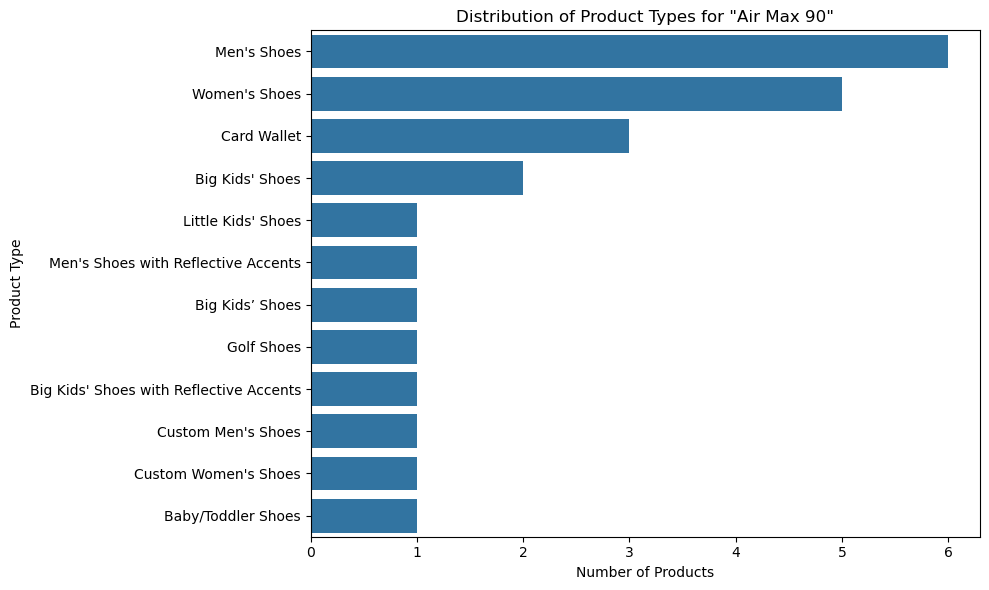

In [20]:
print("Plotting Histogram for Product Type")

if not df_results.empty and 'Type' in df_results.columns:
        # Create the plot
    plt.figure(figsize=(10, 6)) # Adjust figure size if needed
    sns.countplot(data=df_results, y='Type', order = df_results['Type'].value_counts().index) # Use countplot for categories, order by frequency

    # Add labels and title
    plt.title('Distribution of Product Types for "Air Max 90"')
    plt.xlabel('Number of Products')
    plt.ylabel('Product Type')

    # Improve layout and display the plot
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot histogram. DataFrame might be empty or missing 'Type' column.")

# Discussion

## Data Collection Summary
The web scraping script successfully navigated Nike.com, initiated an automated search for "air max 90", and extracted relevant product details from the first page of search results. Data was collected for 34 items listed, matching the result count displayed on the website. The extracted features included the product name, product type/subtitle, price, and the count of available colorways displayed on the product card. This data was compiled into a structured CSV file (`nike_air_max_90_results.csv`).

## Key Findings & Observations
* **Product Variety:** The search yielded a diverse range of items beyond the standard Men's and Women's Air Max 90 shoes. Results included variations like Premium, LTR, SE, LV8, EasyOn, and Golf shoes, as well as customizable "By You" options. Different age groups were targeted, with listings for Big Kids', Little Kids', and Baby/Toddler shoes. Interestingly, non-footwear items like themed Card Wallets were also included in the results. The bar chart visualization effectively illustrated the frequency of each product type. 
* **Price Distribution:** Prices showed considerable variation, reflecting the product diversity. The minimum price observed was **$30.00** (Card Wallets), while the maximum reached **$210.00** (for a special edition Men's shoe). Standard Men's/Women's shoes clustered around $135.00-$150.00, with Kids' versions priced lower (approx. $65.00 - $112.00) and custom/premium versions priced higher (up to $165.00 for shoes). The **mean price ($117.50)** falls between the main adult shoe price and the kids'/accessory prices, and the **variance ($1564.85)** highlights the wide price spread. Both the histogram and box plot visualizations provided clear views of this distribution and how prices differed across product types. 
* **Colorways:** Many products, particularly the main shoe types, displayed multiple color options (often 5) on the results card. However, several items, including some kids' shoes and special editions, showed 0-3 colors listed, suggesting either limited options or that full color choices require visiting the product detail page.
* **Data Quality:** The scraping process was successful in capturing the targeted data fields for all 34 products without any missing values, as confirmed by the dataset validation checks. Price data required cleaning (removing '$') for numerical analysis.

## Conclusion
The project successfully demonstrated the use of Selenium for automating a product search on a major e-commerce website (Nike.com) and extracting key product details into a structured dataset. The subsequent analysis provided insights into the product variety and pricing strategy for items related to the "air max 90" search term, fulfilling the project's objectives. The process highlighted the importance of identifying stable HTML locators and handling potential variations in website structure or content loading.